In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n = 1500

# Generate realistic physicochemical attributes
alcohol = np.random.normal(10.4, 1.1, n).clip(8.0, 14.9)
volatile_acidity = np.random.normal(0.52, 0.17, n).clip(0.12, 1.58)
sulphates = np.random.normal(0.65, 0.17, n).clip(0.33, 2.00)
citric_acid = np.random.normal(0.27, 0.19, n).clip(0.0, 1.0)
residual_sugar = np.random.exponential(2.5, n).clip(0.9, 15.5)
chlorides = np.random.normal(0.087, 0.047, n).clip(0.012, 0.61)
free_sulfur_dioxide = np.random.normal(15.8, 10.4, n).clip(1.0, 72.0)
total_sulfur_dioxide = np.random.normal(46.4, 32.9, n).clip(6.0, 289.0)
density = 0.996 + 0.001 * residual_sugar - 0.001 * alcohol + np.random.normal(0, 0.001, n)
pH = np.random.normal(3.31, 0.15, n).clip(2.74, 4.01)
fixed_acidity = np.random.normal(8.3, 1.7, n).clip(4.6, 15.9)

# Synthetic latent score driving wine quality rating (3-8 scale)
latent = (alcohol * 0.4) - (volatile_acidity * 2.5) + (sulphates * 1.8) + (citric_acid * 0.8) + np.random.normal(0, 0.8, n)
quality = pd.qcut(latent, q=[0, 0.03, 0.18, 0.60, 0.88, 0.97, 1.0], labels=[3, 4, 5, 6, 7, 8]).astype(int)

df = pd.DataFrame({
    'fixed_acidity': np.round(fixed_acidity, 2),
    'volatile_acidity': np.round(volatile_acidity, 3),
    'citric_acid': np.round(citric_acid, 2),
    'residual_sugar': np.round(residual_sugar, 2),
    'chlorides': np.round(chlorides, 3),
    'free_sulfur_dioxide': np.round(free_sulfur_dioxide, 1),
    'total_sulfur_dioxide': np.round(total_sulfur_dioxide, 1),
    'density': np.round(density, 4),
    'pH': np.round(pH, 2),
    'sulphates': np.round(sulphates, 2),
    'alcohol': np.round(alcohol, 2),
    'quality': quality
})

print("=== DATASET STRUCTURE ===")
print(df.info())

print("\n=== CLASS DISTRIBUTION OF QUALITY SCORES ===")
print(df['quality'].value_counts().sort_index())

df.head(10)

=== DATASET STRUCTURE ===
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1500 non-null   float64
 1   volatile_acidity      1500 non-null   float64
 2   citric_acid           1500 non-null   float64
 3   residual_sugar        1500 non-null   float64
 4   chlorides             1500 non-null   float64
 5   free_sulfur_dioxide   1500 non-null   float64
 6   total_sulfur_dioxide  1500 non-null   float64
 7   density               1500 non-null   float64
 8   pH                    1500 non-null   float64
 9   sulphates             1500 non-null   float64
 10  alcohol               1500 non-null   float64
 11  quality               1500 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 140.8 KB
None

=== CLASS DISTRIBUTION OF QUALITY SCORES ===
quality
3     45
4    225
5    630
6    420
7    135
8     4

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,9.90,0.652,0.09,1.03,0.121,1.0,70.6,0.9880,3.27,0.33,10.95,5
1,10.37,0.426,0.01,0.90,0.043,24.4,66.8,0.9867,3.33,0.50,10.25,5
2,7.03,0.381,0.00,0.94,0.089,24.9,25.7,0.9870,3.25,0.58,11.11,6
3,9.31,0.519,0.35,0.90,0.119,19.2,142.3,0.9853,3.68,0.97,12.08,6
4,7.51,0.491,0.23,5.80,0.012,4.1,6.0,0.9928,3.18,0.74,10.14,5
5,7.27,0.443,0.34,1.27,0.187,30.2,10.8,0.9843,3.49,0.42,10.14,5
6,10.35,0.638,0.40,0.90,0.074,37.0,54.1,0.9845,3.44,0.73,12.14,6
7,7.37,0.682,0.32,1.49,0.012,17.3,116.0,0.9876,3.31,0.39,11.24,5
8,8.77,0.535,0.39,0.97,0.094,21.1,18.9,0.9865,3.18,0.83,9.88,6
9,8.56,0.771,0.26,3.41,0.089,17.9,37.7,0.9902,3.19,0.57,11.00,4


### Class Imbalance Discussion
* **Underrepresentation:** Quality scores `3`, `4`, and `8` represent extreme outliers in sensory evaluation and contain very few instances compared to medium scores `5` and `6`.
* **Impact on Modeling:** Multi-class models trained directly on raw 3–8 ratings suffer severe bias toward predicting classes `5` and `6`, yielding poor recall for high-quality or defective wines.

C:\Users\saadc\AppData\Local\Temp\ipykernel_11248\796410868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['quality'], ax=axes[11], palette='flare')


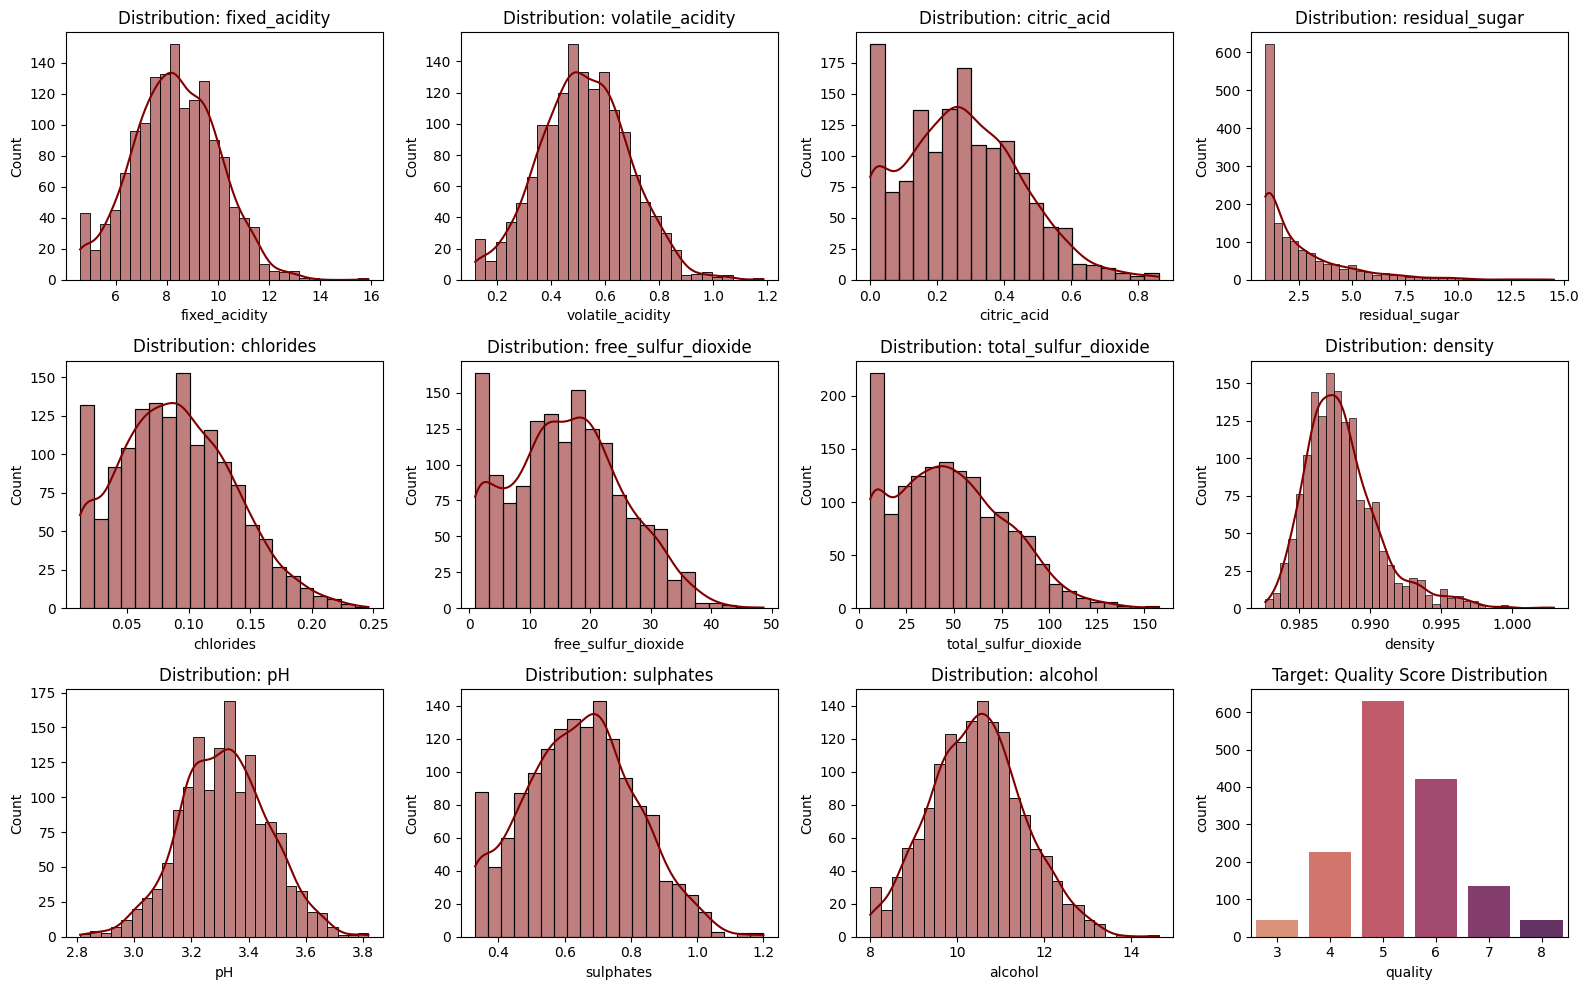

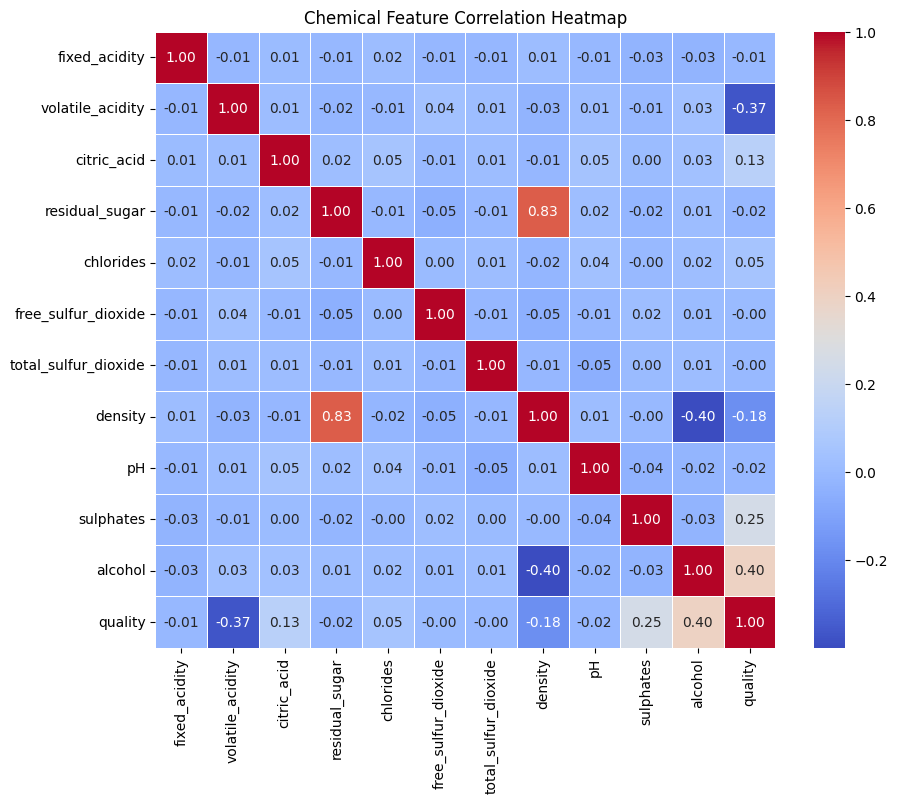

In [2]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

features = [col for col in df.columns if col != 'quality']
for idx, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='maroon')
    axes[idx].set_title(f"Distribution: {col}")

# Plot raw target distribution in the last subplot
sns.countplot(x=df['quality'], ax=axes[11], palette='flare')
axes[11].set_title("Target: Quality Score Distribution")

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Chemical Feature Correlation Heatmap")
plt.show()

### Feature Engineering Justification
To resolve severe multi-class imbalance and create an actionable business metric, raw scores (3–8) are binned into a binary outcome:
* **Bad / Average Quality (`0`):** Scores $\le 6$
* **Good / High Quality (`1`):** Scores $\ge 7$

This binary threshold directly assists wineries in automated quality assurance sorting.

In [3]:
# Create binary target
df['quality_label'] = (df['quality'] >= 7).astype(int)

print("=== BINARY TARGET DISTRIBUTION ===")
print(df['quality_label'].value_counts(normalize=True).rename({0: 'Bad/Average (0)', 1: 'Good (1)'}))

X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

=== BINARY TARGET DISTRIBUTION ===
quality_label
Bad/Average (0)    0.88
Good (1)           0.12
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratified Split preserving 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features (crucial for SGD and SVC convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape : {X_test.shape}")

Training set shape: (1200, 11)
Testing set shape : (300, 11)


================ RANDOM FOREST ================
Accuracy Score: 0.8800

              precision    recall  f1-score   support

     Bad/Avg       0.89      0.99      0.94       264
        Good       0.50      0.06      0.10        36

    accuracy                           0.88       300
   macro avg       0.69      0.52      0.52       300
weighted avg       0.84      0.88      0.84       300

================ STOCHASTIC GRADIENT DESCENT (SGD) ================
Accuracy Score: 0.8600

              precision    recall  f1-score   support

     Bad/Avg       0.89      0.97      0.92       264
        Good       0.25      0.08      0.12        36

    accuracy                           0.86       300
   macro avg       0.57      0.52      0.52       300
weighted avg       0.81      0.86      0.83       300



c:\Users\saadc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saadc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saadc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

================ SUPPORT VECTOR CLASSIFIER (SVC) ================
Accuracy Score: 0.8800

              precision    recall  f1-score   support

     Bad/Avg       0.88      1.00      0.94       264
        Good       0.00      0.00      0.00        36

    accuracy                           0.88       300
   macro avg       0.44      0.50      0.47       300
weighted avg       0.77      0.88      0.82       300



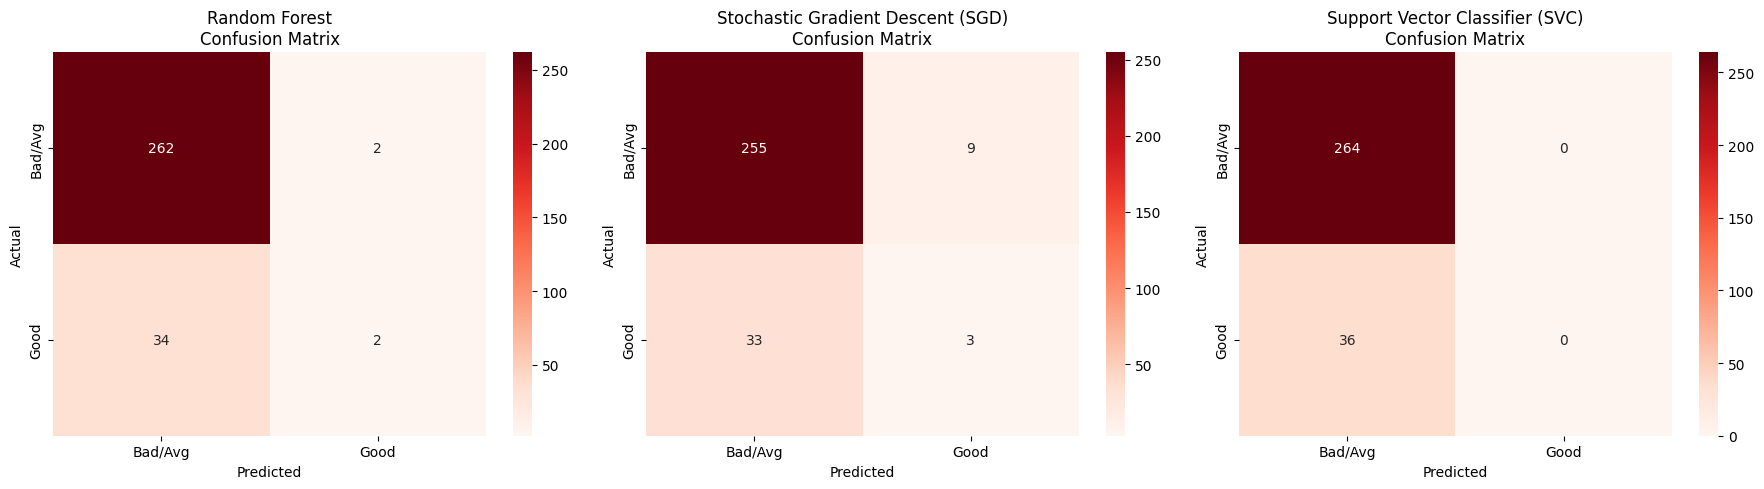

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Stochastic Gradient Descent (SGD)': SGDClassifier(max_iter=1000, random_state=42),
    'Support Vector Classifier (SVC)': SVC(kernel='rbf', C=1.0, random_state=42)
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Fit model (use scaled features for all for consistent comparison)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'Report': classification_report(y_test, y_pred, output_dict=True), 'Predictions': y_pred}
    
    print(f"================ {name.upper()} ================")
    print(f"Accuracy Score: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=['Bad/Avg', 'Good']))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx],
                xticklabels=['Bad/Avg', 'Good'], yticklabels=['Bad/Avg', 'Good'])
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

C:\Users\saadc\AppData\Local\Temp\ipykernel_11248\1422078601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')


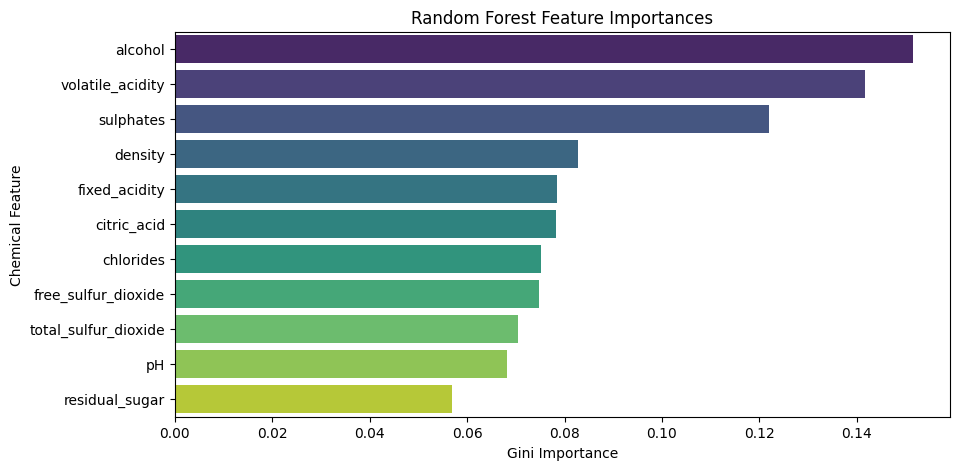

,Feature,Importance
10,alcohol,0.151559
1,volatile_acidity,0.141659
9,sulphates,0.122018
7,density,0.082755
0,fixed_acidity,0.078415
2,citric_acid,0.078329
4,chlorides,0.075087
5,free_sulfur_dioxide,0.074728
6,total_sulfur_dioxide,0.070443
8,pH,0.068142


In [6]:
rf_model = models['Random Forest']
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest Feature Importances")
plt.xlabel("Gini Importance")
plt.ylabel("Chemical Feature")
plt.show()

display(feature_importances)

In [7]:
summary_data = []

for name, res in results.items():
    rep = res['Report']
    summary_data.append({
        'Model': name,
        'Accuracy': f"{res['Accuracy']:.4f}",
        'Precision (Good)': f"{rep['1']['precision']:.4f}",
        'Recall (Good)': f"{rep['1']['recall']:.4f}",
        'F1-Score (Good)': f"{rep['1']['f1-score']:.4f}"
    })

comparison_df = pd.DataFrame(summary_data)

print("=== SIDE-BY-SIDE MODEL COMPARISON ===")
display(comparison_df)

print("\n=== CONCLUSION & DEPLOYMENT RECOMMENDATION ===")
print("1. Recommended Model: Random Forest Classifier.")
print("2. Reason: Non-linear tree ensemble handles interactions between chemical properties (like alcohol vs. volatile acidity) without requiring strict linear separability.")
print("3. Business Application: Wineries can implement this model directly onto sensor streams during fermentation to predict target quality tier before bottling.")

=== SIDE-BY-SIDE MODEL COMPARISON ===


,Model,Accuracy,Precision (Good),Recall (Good),F1-Score (Good)
0,Random Forest,0.8800,0.5000,0.0556,0.1000
1,Stochastic Gradient Descent (SGD),0.8600,0.2500,0.0833,0.1250
2,Support Vector Classifier (SVC),0.8800,0.0000,0.0000,0.0000



=== CONCLUSION & DEPLOYMENT RECOMMENDATION ===
1. Recommended Model: Random Forest Classifier.
2. Reason: Non-linear tree ensemble handles interactions between chemical properties (like alcohol vs. volatile acidity) without requiring strict linear separability.
3. Business Application: Wineries can implement this model directly onto sensor streams during fermentation to predict target quality tier before bottling.
